In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import random
from scipy.sparse import csr_matrix, csc_matrix
from scipy.io import mmread
from scipy.stats import mannwhitneyu

In [3]:
sc.logging.print_header()
sc.settings.set_figure_params(dpi_save=600, facecolor='white', fontsize=7, format='pdf')

scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.4 igraph==0.11.8 louvain==0.8.1 pynndescent==0.5.13


In [4]:
random.seed(71444)

In [5]:
ad.logging.print_memory_usage()

Memory usage: current 0.55 GB, difference +0.55 GB


In [6]:
outdir = '/cluster/home/chenyulong/GSE165816/0.1out'
os.chdir(outdir)

In [7]:
adata=sc.read_h5ad("./Final_ann.h5ad")

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
adata.var

,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
A2M-AS1,619,False,619,0.010976,98.933402,637.0,True,0.012331,0.968680,0.906028,0.007042,0.081161
A2ML1,1601,False,1601,0.066046,97.241320,3833.0,True,0.014164,0.996382,0.964582,0.008104,0.086260
AARD,718,False,718,0.038098,98.762816,2211.0,True,0.010641,0.952344,0.871500,0.006060,0.075525
AATK,387,False,387,0.007444,99.333161,432.0,True,0.005799,1.090253,1.162997,0.003276,0.055514
ABALON,76,False,76,0.001327,99.869045,77.0,True,0.001495,0.890430,0.740633,0.000828,0.028967
...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF813,1028,False,1028,0.018678,98.228655,1084.0,True,0.012975,0.851970,0.659340,0.008026,0.079924
ZNF821,3454,False,3454,0.064702,94.048419,3755.0,True,0.051328,0.832766,0.618750,0.031897,0.160757
ZNF831,689,False,689,0.013630,98.812785,791.0,True,0.029184,1.215054,1.426786,0.014421,0.131889
ZP2,6,False,6,0.000103,99.989661,6.0,True,0.000233,1.536962,2.107200,0.000099,0.011716


In [ ]:
genes_of_interest = ["TNFRSF1A", "HLA-E", "IL19", "CA12",  "JAM2", 'DLL1', "ADM", "FAM19A5",  'BTN2A1', 
                     "CTSB", "RSPO3", "ASGR1", "CD27", "THY1", 'CSF1', "TNFRSF9", 'DPY30' ]
print([gene for gene in genes_of_interest if gene in adata.raw.var_names])

['TNFRSF1A', 'JAM2', 'CTSB', 'SDC4', 'HLA-E', 'DLL1', 'THY1', 'CSF1', 'IL19', 'ADM', 'FAM19A5', 'ASGR1', 'TNFRSF9', 'CA12', 'BTN2A1', 'CD27', 'DPY30']


In [9]:
valid_genes = [gene for gene in genes_of_interest if gene in adata.raw.var_names]
adata_subset = adata.raw[:, valid_genes].to_adata()

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
adata_subset.write("subset_genes.h5ad")

In [11]:
adata_subset.obs = adata.obs
adata_subset.var = adata.raw.var.loc[valid_genes]

In [12]:
adata_loaded = sc.read("subset_genes.h5ad")
print(adata_loaded)

AnnData object with n_obs × n_vars = 47758 × 17
    obs: 'sample', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'group', 'celltype'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'group_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'


/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
adata_loaded.obs

,sample,doublet_score,predicted_doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,group,celltype
AAACCTGCATGTAAGA,G1A,0.007333,False,1109,1109,2493.0,138.0,5.535500,VSMC,control,VSMC
AAACCTGGTGTGACGA,G1A,0.019476,False,832,832,1487.0,52.0,3.496974,Endothelial Cell,control,Endothelial Cell
AAACGGGAGGCTACGA,G1A,0.039250,False,2730,2730,9072.0,142.0,1.565256,Fibroblast,control,Fibroblast
AAACGGGTCTTGTTTG,G1A,0.048657,False,1501,1501,3134.0,59.0,1.882578,Endothelial Cell,control,Endothelial Cell
AAAGATGGTCAGAGGT,G1A,0.007567,False,1078,1078,2467.0,30.0,1.216052,Fibroblast,control,Fibroblast
...,...,...,...,...,...,...,...,...,...,...,...
TTTGGAGTCCATACAG-1,G49,0.045932,False,1797,1797,5257.0,654.0,12.440556,VSMC,DFU,VSMC
TTTGGTTCAGACAATA-1,G49,0.035954,False,3937,3937,15276.0,1122.0,7.344855,VSMC,DFU,VSMC
TTTGGTTTCCGTCCTA-1,G49,0.041031,False,3671,3671,13450.0,485.0,3.605948,VSMC,DFU,VSMC
TTTGTTGAGAATTCAG-1,G49,0.018638,False,2282,2282,4863.0,526.0,10.816368,Endothelial Cell,DFU,Endothelial Cell


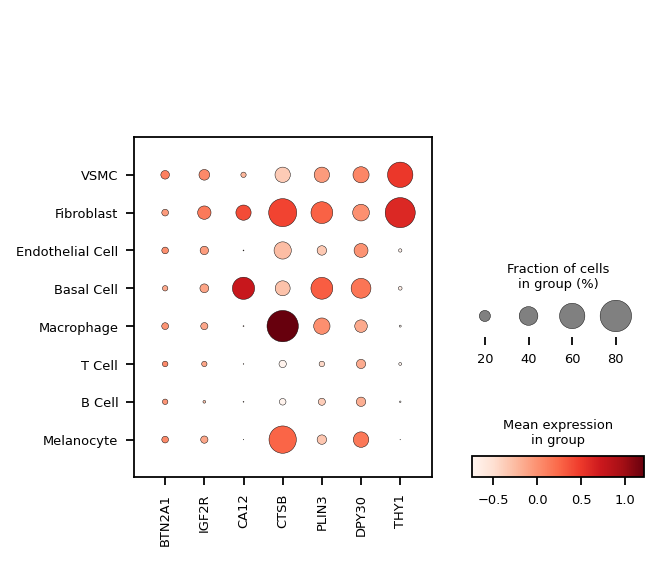

In [16]:
sc.pl.dotplot(adata_loaded,  ['BTN2A1','IGF2R','CA12','CTSB','PLIN3','DPY30','THY1'], save='.ran1se.pdf', groupby='leiden' )

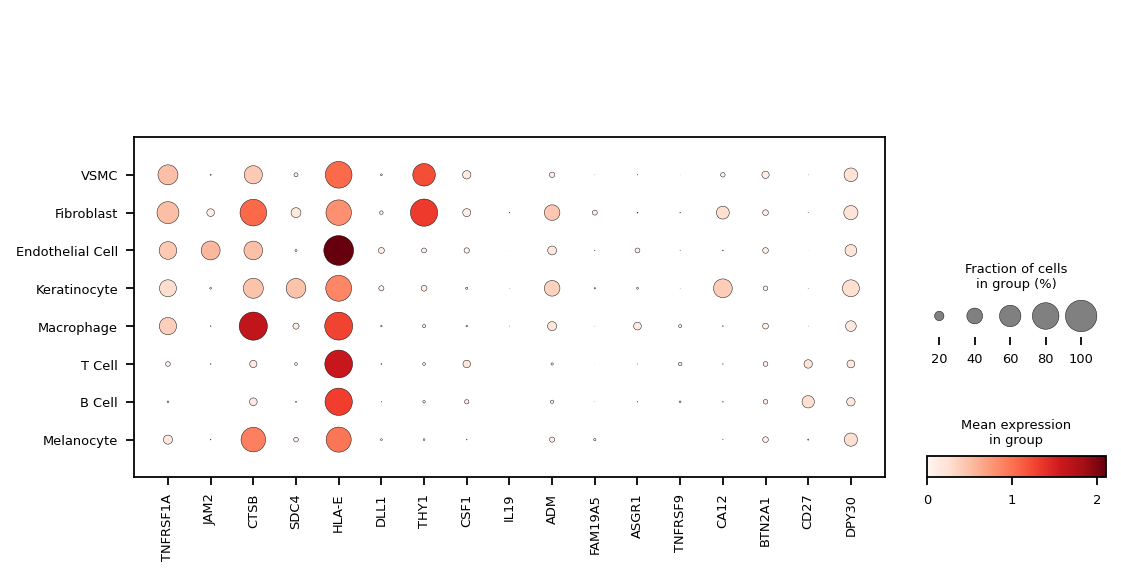

In [ ]:
sc.pl.dotplot(adata_loaded,  ["TNFRSF1A", "HLA-E", "IL19", "CA12",  "JAM2", 'DLL1', "ADM", "FAM19A5",  'BTN2A1', 
                     "CTSB", "RSPO3", "ASGR1", "CD27", "THY1", 'CSF1', "TNFRSF9", 'DPY30'], save='.ran2se.pdf', groupby='leiden' )

实际的leiden cluster数量: 8
Leiden categories: ['VSMC', 'Fibroblast', 'Endothelial Cell', 'Keratinocyte', 'Macrophage', 'T Cell', 'B Cell', 'Melanocyte']
使用前 8 个颜色
Leiden colors: ['#1f77b4' '#ff7f0e' '#279e68' '#d62728' '#aa40fc' '#8c564b' '#e377c2'
 '#b5bd61']

图片已保存为: stacked_violin.ran2se.pdf


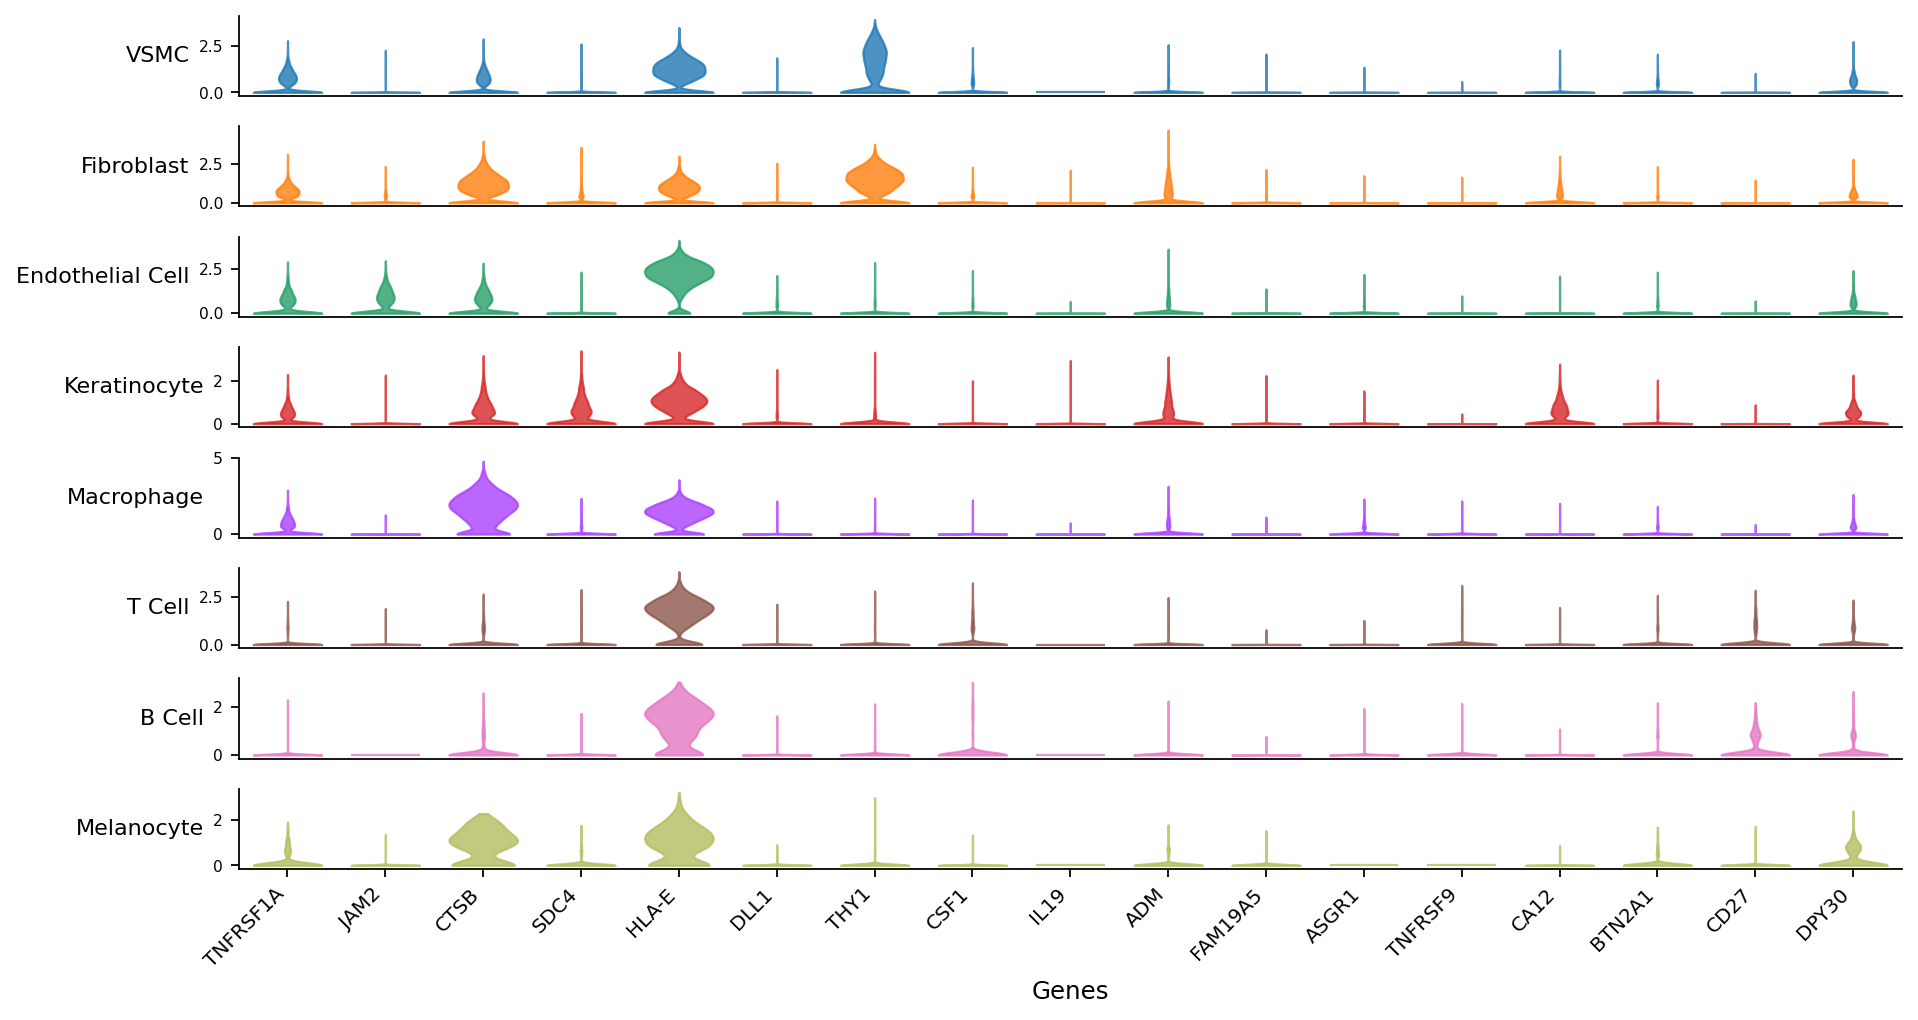

In [39]:
n_clusters_actual = len(adata_loaded.obs['leiden'].cat.categories)
print(f"实际的leiden cluster数量: {n_clusters_actual}")
print(f"Leiden categories: {adata_loaded.obs['leiden'].cat.categories.tolist()}")

if 'leiden_colors' in adata_loaded.uns:
    leiden_colors = adata_loaded.uns['leiden_colors'][:n_clusters_actual]
    print(f"使用前 {n_clusters_actual} 个颜色")
    print("Leiden colors:", leiden_colors)
else:
    leiden_colors = [plt.cm.tab20(i) for i in range(n_clusters_actual)]

genes = ['TNFRSF1A', 'JAM2', 'CTSB', 'SDC4', 'HLA-E', 'DLL1', 'THY1', 'CSF1', 
         'IL19', 'ADM', 'FAM19A5', 'ASGR1', 'TNFRSF9', 'CA12', 'BTN2A1', 'CD27', 'DPY30']

leiden_cats = adata_loaded.obs['leiden'].cat.categories

fig, axes = plt.subplots(len(leiden_cats), 1, figsize=(12, len(leiden_cats)*0.8), sharex=True)

for idx, cluster in enumerate(leiden_cats):
    ax = axes[idx]
    
    
    data_list = []
    positions = []
    
    for i, gene in enumerate(genes):
       
        mask = adata_loaded.obs['leiden'] == cluster
        cluster_data = adata_loaded[mask, gene].X
        
        
        if hasattr(cluster_data, 'toarray'):
            cluster_data = cluster_data.toarray().flatten()
        else:
            cluster_data = np.array(cluster_data).flatten()
        
        data_list.append(cluster_data)
        positions.append(i)
    
    
    parts = ax.violinplot(data_list, positions=positions, widths=0.7, 
                          showmeans=False, showmedians=False, showextrema=False)
    
    
    for pc in parts['bodies']:
        pc.set_facecolor(leiden_colors[idx])
        pc.set_edgecolor(leiden_colors[idx])
        pc.set_alpha(0.8)
    
  
    ax.grid(False)
    
   
    ax.set_ylabel(f'{cluster}', rotation=0, ha='right', va='center', fontsize=10)
    ax.set_xlim(-0.5, len(genes) - 0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
   
    if idx == len(leiden_cats) - 1:
        ax.set_xticks(range(len(genes)))
        ax.set_xticklabels(genes, rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('Genes', fontsize=11)
    else:
        ax.set_xticks([])
        ax.tick_params(axis='x', which='both', length=0)

plt.tight_layout()
plt.savefig('stacked_violin.ran2se.pdf', bbox_inches='tight', dpi=300)
print("\n图片已保存为: stacked_violin.ran2se.pdf")
plt.show()

In [ ]:
def calculate_signature_per_cell(adata, genes):
    expression_matrix = adata[:, valid_genes].X.toarray() if hasattr(adata.X, "toarray") else adata[:, valid_genes].X
    
    signatures = np.sum(expression_matrix, axis=1)
    return signatures

def analyze_signature_by_celltype(adata, signatures, cell_type_col='celltype'):
    adata.obs['Signature'] = signatures
  
    summary_df = adata.obs.groupby(cell_type_col)['Signature'].agg(['mean', 'median', 'std', 'count']).reset_index()
    summary_df.rename(columns={
        'mean': 'MeanSignature',
        'median': 'MedianSignature',
        'std': 'StdDevSignature',
        'count': 'CellCount'
    }, inplace=True)
    return summary_df
genes_of_interest = ['TNFRSF1A', 'JAM2', 'CTSB', 'SDC4', 'HLA-E', 'DLL1',  'THY1', 'CSF1', 'IL19', 'ADM', 'FAM19A5',
                     'ASGR1', 'TNFRSF9', 'CA12', 'BTN2A1', 'CD27', 'DPY30']
signatures = calculate_signature_per_cell(adata_loaded, genes_of_interest)
signature_summary = analyze_signature_by_celltype(adata_loaded, signatures)
print(signature_summary)
##signature_summary.to_csv("signature_summary_by_celltype.csv", index=False)

/tmp/ipykernel_85994/365821274.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = adata.obs.groupby(cell_type_col)['Signature'].agg(['mean', 'median', 'std', 'count']).reset_index()


           celltype  MeanSignature  MedianSignature  StdDevSignature  \
0              VSMC       3.841894         3.846267         1.840381   
1        Fibroblast       5.089589         5.078250         2.007553   
2  Endothelial Cell       4.330135         4.436889         1.661694   
3      Keratinocyte       3.388515         3.419359         1.674472   
4        Macrophage       4.024748         4.072598         1.788728   
5            T Cell       2.665798         2.559073         1.470185   
6            B Cell       2.170594         2.101332         1.216629   
7        Melanocyte       2.599317         2.578378         1.304338   

   CellCount  
0      13243  
1      13219  
2       5075  
3       4936  
4       4892  
5       4867  
6       1192  
7        334  


In [ ]:
def calculate_signature_per_cell(adata, genes):
    expression_matrix = adata[:, genes].X.toarray() if hasattr(adata.X, "toarray") else adata[:, genes].X
    
    signatures = np.sum(expression_matrix, axis=1)
    return signatures

def analyze_signature_by_celltype(adata, signatures, cell_type_col='celltype'):
    adata.obs['Signature'] = signatures
    
    summary_df = adata.obs.groupby(cell_type_col)['Signature'].agg(['mean', 'median', 'std', 'count']).reset_index()
    summary_df.rename(columns={
        'mean': 'MeanSignature',
        'median': 'MedianSignature',
        'std': 'StdDevSignature',
        'count': 'CellCount'
    }, inplace=True)
    return summary_df

genes_of_interest = ['TNFRSF1A', 'JAM2', 'CTSB', 'SDC4', 'HLA-E', 'DLL1',  'THY1', 'CSF1', 'IL19', 'ADM', 'FAM19A5',
                     'ASGR1', 'TNFRSF9', 'CA12', 'BTN2A1', 'CD27', 'DPY30']
signatures = calculate_signature_per_cell(adata_loaded, genes_of_interest)
signature_summary = analyze_signature_by_celltype(adata_loaded, signatures)

signatures_with_celltype = pd.DataFrame({'Signature': signatures, 'celltype': adata_loaded.obs['celltype']})
with pd.ExcelWriter("signatures.xlsx") as writer:
    signatures_with_celltype.to_excel(writer, sheet_name='Signatures')

/tmp/ipykernel_85994/3200620735.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = adata.obs.groupby(cell_type_col)['Signature'].agg(['mean', 'median', 'std', 'count']).reset_index()


In [16]:
cell_types = adata_loaded.obs['celltype'].unique()

results = []

for cell_type in cell_types:
    subset_data = adata_loaded.obs[adata_loaded.obs['celltype'] == cell_type]
    

    group1_data = subset_data[subset_data['group'] == 'control']['Signature'].dropna()
    group2_data = subset_data[subset_data['group'] == 'DFU']['Signature'].dropna()
    

    if not group1_data.empty and not group2_data.empty:
     
        stat, p_value = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
        results.append({'celltype': cell_type, 'p_value': p_value})
    else:
        
        results.append({'celltype': cell_type, 'p_value': None})

for result in results:
    print(f"Cell Type: {result['celltype']}, P-Value: {result['p_value']}")

Cell Type: VSMC, P-Value: 4.867047050140642e-37
Cell Type: Endothelial Cell, P-Value: 3.680729311941107e-05
Cell Type: Fibroblast, P-Value: 1.0886158715647847e-79
Cell Type: T Cell, P-Value: 0.5552698168939842
Cell Type: Macrophage, P-Value: 9.914653525327298e-22
Cell Type: Keratinocyte, P-Value: 6.478871783695922e-30
Cell Type: B Cell, P-Value: 0.10585681324009708
Cell Type: Melanocyte, P-Value: 0.04444733984749595


In [17]:
dfu_data = adata_loaded.obs[adata_loaded.obs['group'] == 'DFU']['Signature'].dropna()
control_data = adata_loaded.obs[adata_loaded.obs['group'] == 'control']['Signature'].dropna()

if not dfu_data.empty and not control_data.empty:
    
    stat, p_value = mannwhitneyu(control_data, dfu_data, alternative='two-sided')
    print(f"Overall P-Value between DFU and Control: {p_value}")
else:
    print("Either DFU or Control group has no data for Signature.")

Overall P-Value between DFU and Control: 6.756860974377309e-23


In [18]:
import itertools

adata_loaded.obs['Signature'] = signatures  
plot_data = adata_loaded.obs[['Signature', 'celltype']]


celltypes = plot_data['celltype'].unique()
p_values = {}

for group1, group2 in itertools.combinations(celltypes, 2):
    group1_data = plot_data[plot_data['celltype'] == group1]['Signature']
    group2_data = plot_data[plot_data['celltype'] == group2]['Signature']
    
  
    stat, p = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
    p_values[(group1, group2)] = p

for key, p in p_values.items():
    print(f"比较 {key[0]} 和 {key[1]} 的 p 值: {p}")

比较 VSMC 和 Endothelial Cell 的 p 值: 1.4172174811527369e-65
比较 VSMC 和 Fibroblast 的 p 值: 0.0
比较 VSMC 和 T Cell 的 p 值: 0.0
比较 VSMC 和 Macrophage 的 p 值: 2.9522984651709885e-09
比较 VSMC 和 Keratinocyte 的 p 值: 1.7142866275538675e-46
比较 VSMC 和 B Cell 的 p 值: 1.6947776720806873e-207
比较 VSMC 和 Melanocyte 的 p 值: 1.0969253240743469e-35
比较 Endothelial Cell 和 Fibroblast 的 p 值: 6.848151930060459e-119
比较 Endothelial Cell 和 T Cell 的 p 值: 0.0
比较 Endothelial Cell 和 Macrophage 的 p 值: 1.1414781509354431e-21
比较 Endothelial Cell 和 Keratinocyte 的 p 值: 1.2660018289852572e-175
比较 Endothelial Cell 和 B Cell 的 p 值: 0.0
比较 Endothelial Cell 和 Melanocyte 的 p 值: 5.018854044360724e-74
比较 Fibroblast 和 T Cell 的 p 值: 0.0
比较 Fibroblast 和 Macrophage 的 p 值: 1.032878825618946e-223
比较 Fibroblast 和 Keratinocyte 的 p 值: 0.0
比较 Fibroblast 和 B Cell 的 p 值: 0.0
比较 Fibroblast 和 Melanocyte 的 p 值: 1.012768010016745e-107
比较 T Cell 和 Macrophage 的 p 值: 0.0
比较 T Cell 和 Keratinocyte 的 p 值: 9.044632361486435e-120
比较 T Cell 和 B Cell 的 p 值: 4.0772949

In [19]:
signature_stats = plot_data.groupby('celltype')['Signature'].agg(['mean', 'std'])

signature_stats_formatted = signature_stats.apply(
    lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1
)

print("Mean ± SD for Each Cell Type:")
print(signature_stats_formatted)

Mean ± SD for Each Cell Type:
celltype
VSMC                3.84 ± 1.84
Fibroblast          5.09 ± 2.01
Endothelial Cell    4.33 ± 1.66
Keratinocyte        3.39 ± 1.67
Macrophage          4.02 ± 1.79
T Cell              2.67 ± 1.47
B Cell              2.17 ± 1.22
Melanocyte          2.60 ± 1.30
dtype: object


/tmp/ipykernel_85994/55819554.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature_stats = plot_data.groupby('celltype')['Signature'].agg(['mean', 'std'])


In [20]:
plot_data = adata_loaded.obs[['celltype', 'group', 'Signature']].dropna()
signature_stats = plot_data.groupby(['celltype', 'group'])['Signature'].agg(['mean', 'std']).reset_index()

signature_stats['Signature (mean ± SD)'] = signature_stats.apply(
    lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1
)

formatted_output = signature_stats[['celltype', 'group', 'Signature (mean ± SD)']]

print("Mean ± SD of Signature for Each Group within Each Cell Type:")
print(formatted_output)

Mean ± SD of Signature for Each Group within Each Cell Type:
            celltype    group Signature (mean ± SD)
0               VSMC      DFU           3.94 ± 1.85
1               VSMC  control           3.44 ± 1.76
2         Fibroblast      DFU           5.28 ± 2.01
3         Fibroblast  control           4.56 ± 1.90
4   Endothelial Cell      DFU           4.27 ± 1.70
5   Endothelial Cell  control           4.48 ± 1.56
6       Keratinocyte      DFU           3.52 ± 1.69
7       Keratinocyte  control           2.90 ± 1.51
8         Macrophage      DFU           4.11 ± 1.75
9         Macrophage  control           3.28 ± 1.95
10            T Cell      DFU           2.67 ± 1.47
11            T Cell  control           2.66 ± 1.49
12            B Cell      DFU           2.16 ± 1.19
13            B Cell  control           2.49 ± 1.63
14        Melanocyte      DFU           2.52 ± 1.25
15        Melanocyte  control           2.91 ± 1.47


/tmp/ipykernel_85994/1000448119.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature_stats = plot_data.groupby(['celltype', 'group'])['Signature'].agg(['mean', 'std']).reset_index()


In [21]:
signature_stats = plot_data.groupby('group')['Signature'].agg(['mean', 'std']).reset_index()

signature_stats['Signature (mean ± SD)'] = signature_stats.apply(
    lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1
)

formatted_output = signature_stats[['group', 'Signature (mean ± SD)']]

print("Mean ± SD of Signature for Each Group:")
print(formatted_output)

Mean ± SD of Signature for Each Group:
     group Signature (mean ± SD)
0      DFU           4.09 ± 1.99
1  control           3.86 ± 1.89


/tmp/ipykernel_85994/2929755220.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature_stats = plot_data.groupby('group')['Signature'].agg(['mean', 'std']).reset_index()


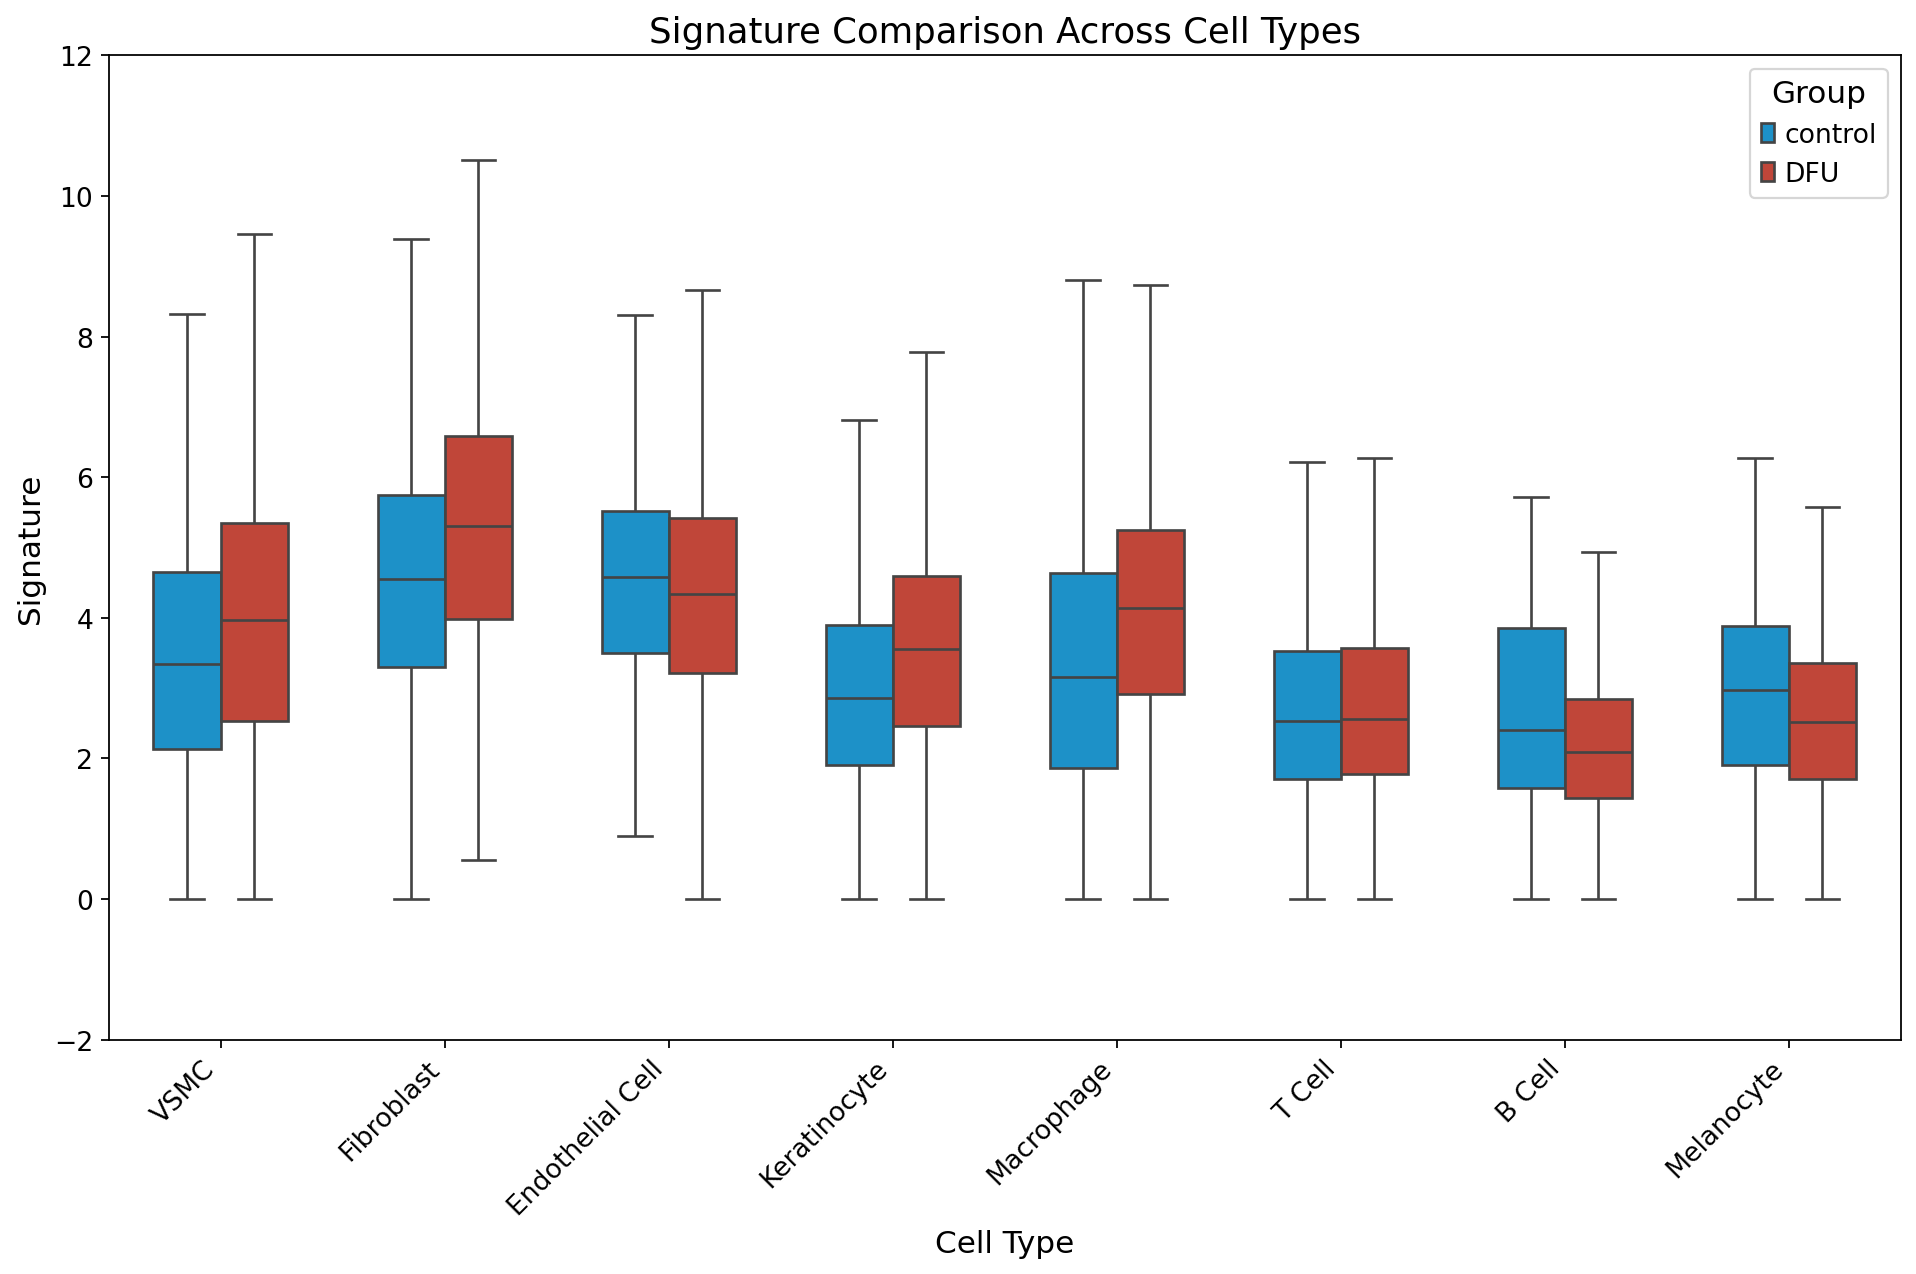

In [22]:
plot_data = adata_loaded.obs[['celltype', 'group', 'Signature']].dropna()

if plot_data.empty:
    print("No data available for plotting. Please check the dataset.")
else:
    
    plt.figure(figsize=(12, 8))
    sns.boxplot(
        x='celltype', 
        y='Signature', 
        hue='group', 
        data=plot_data, 
        width=0.6, 
        palette={'control': '#009CE4', 'DFU': '#D63423'},  
        linewidth=1.2,  
        fliersize=0,  
        hue_order=['control', 'DFU']  
    )


    plt.title("Signature Comparison Across Cell Types", fontsize=16)
    plt.xlabel("Cell Type", fontsize=14)
    plt.ylabel("Signature", fontsize=14)


    plt.xticks(fontsize=12, rotation=45, ha='right')  
    plt.yticks(fontsize=12)

    
    plt.ylim(-2, 12)  


    plt.grid(False)


    plt.legend(title='Group', fontsize=12, title_fontsize=14, loc='upper right')

 
    plt.tight_layout()


    plt.savefig("signature_boxplot_all_celltypes.pdf", dpi=300, bbox_inches='tight')

    plt.show()

/tmp/ipykernel_85994/2738587718.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


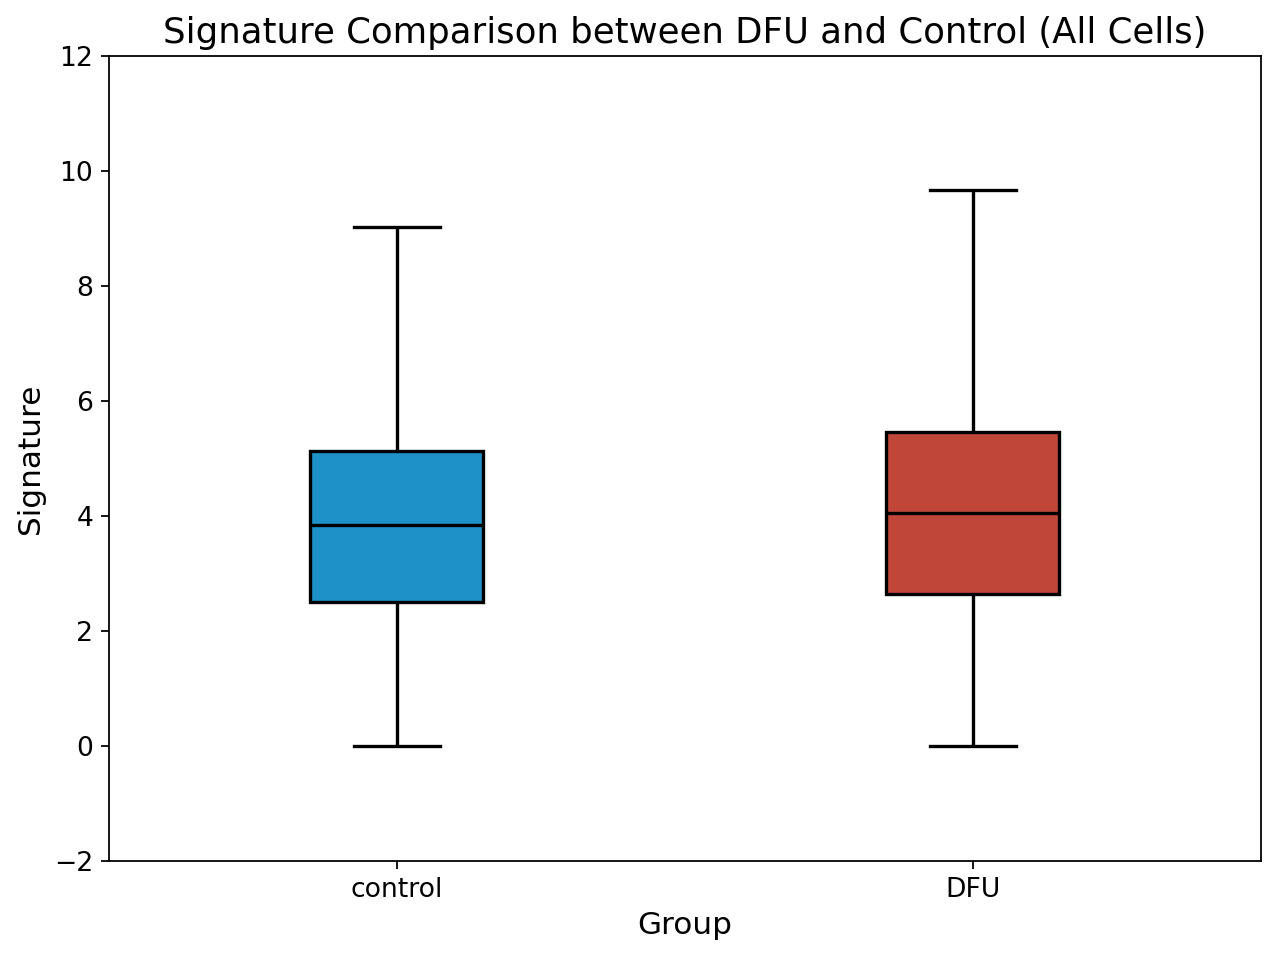

In [23]:
subset_data = adata_loaded.obs[['group', 'Signature']].dropna()

if subset_data.empty:
    print("No data available for 'Signature' or 'group'. Please check the dataset.")
else:
  
    plt.figure(figsize=(8, 6))

    sns.boxplot(
            x='group',
            y='Signature',
            data=subset_data,
            width=0.3,  
            fliersize=0,  
            linewidth=0.8,  
            order=['control', 'DFU'],  
            palette={'control': '#009CE4', 'DFU': '#D63423'},  
            boxprops=dict(edgecolor='black', linewidth=1.5),  
            whiskerprops=dict(color='black', linewidth=1.5),  
            capprops=dict(color='black', linewidth=1.5),      
            medianprops=dict(color='black', linewidth=1.5)    
    )

   
    plt.title("Signature Comparison between DFU and Control (All Cells)", fontsize=16)
    plt.xlabel("Group", fontsize=14)
    plt.ylabel("Signature", fontsize=14)


    plt.ylim(-2, 12)  


    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)


    plt.grid(False)


    plt.tight_layout()
    plt.savefig("signature_C_Total.pdf", dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_85994/2451622182.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


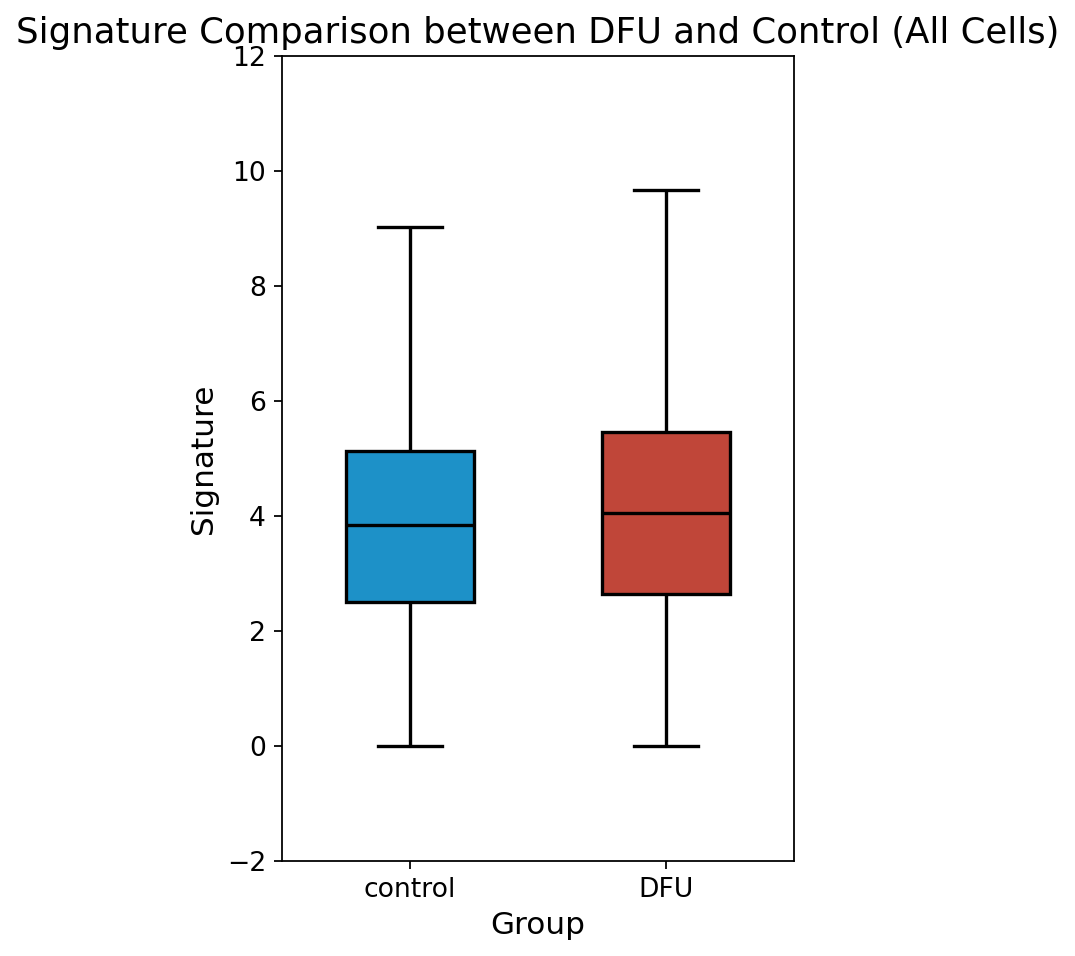

In [26]:
subset_data = adata_loaded.obs[['group', 'Signature']].dropna()

if subset_data.empty:
    print("No data available for 'Signature' or 'group'. Please check the dataset.")
else:
    
    plt.figure(figsize=(4, 6))

    sns.boxplot(
            x='group',
            y='Signature',
            data=subset_data,
            width=0.5,  
            fliersize=0,  
            linewidth=0.8,  
            order=['control', 'DFU'],  
            palette={'control': '#009CE4', 'DFU': '#D63423'},  
            boxprops=dict(edgecolor='black', linewidth=1.5),  
            whiskerprops=dict(color='black', linewidth=1.5),  
            capprops=dict(color='black', linewidth=1.5),      
            medianprops=dict(color='black', linewidth=1.5)    
    )

  
    plt.title("Signature Comparison between DFU and Control (All Cells)", fontsize=16)
    plt.xlabel("Group", fontsize=14)
    plt.ylabel("Signature", fontsize=14)

 
    plt.ylim(-2, 12)  

    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    
    plt.grid(False)

    
    plt.tight_layout()
    plt.savefig("signature_C_Total.pdf", dpi=300, bbox_inches='tight')
    plt.show()

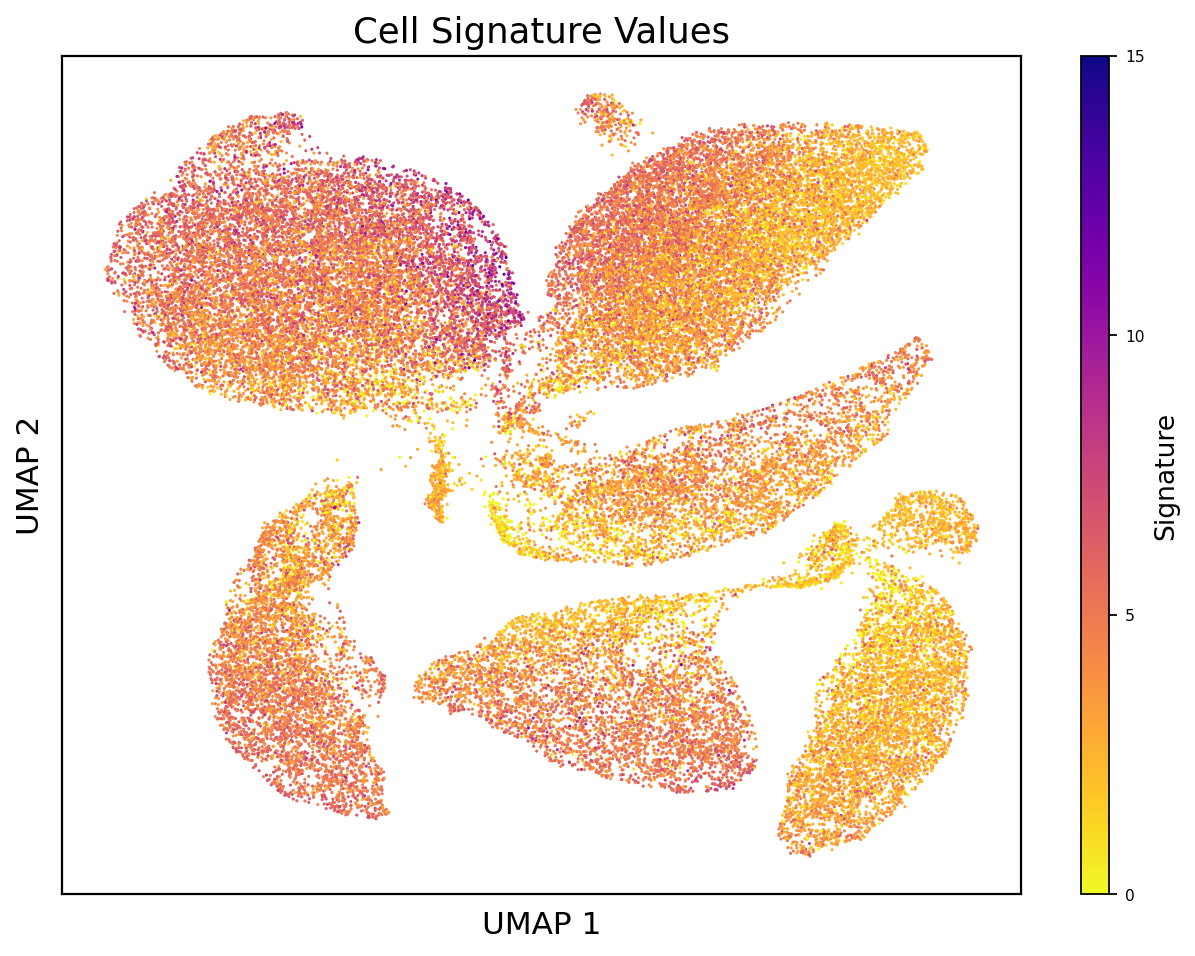

In [61]:
umap_coords = adata_loaded.obsm['X_umap']
adata_loaded.obs['UMAP_1'] = umap_coords[:, 0]
adata_loaded.obs['UMAP_2'] = umap_coords[:, 1]

plot_data = adata_loaded.obs[['UMAP_1', 'UMAP_2', 'Signature']]

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    x=plot_data['UMAP_1'], 
    y=plot_data['UMAP_2'], 
    c=plot_data['Signature'], 
    cmap='plasma_r',        
    edgecolor='none', 
    s=2,                  
    vmin=0,            
    vmax=15             
)


plt.grid(False)


plt.xticks([])
plt.yticks([])


cb = plt.colorbar(sc, aspect=30)
cb.set_label('Signature', fontsize=12)
cb.set_ticks([0, 5, 10, 15])  


plt.title("Cell Signature Values", fontsize=16)
plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)


plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')


plt.gca().spines['top'].set_linewidth(1.0)
plt.gca().spines['right'].set_linewidth(1.0)
plt.gca().spines['left'].set_linewidth(1.0)
plt.gca().spines['bottom'].set_linewidth(1.0)


plt.tight_layout()

plt.savefig("signature_colored.pdf", dpi=600, bbox_inches='tight')

plt.show()

/tmp/ipykernel_297479/94636922.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_297479/94636922.py:13: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_297479/94636922.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=12)


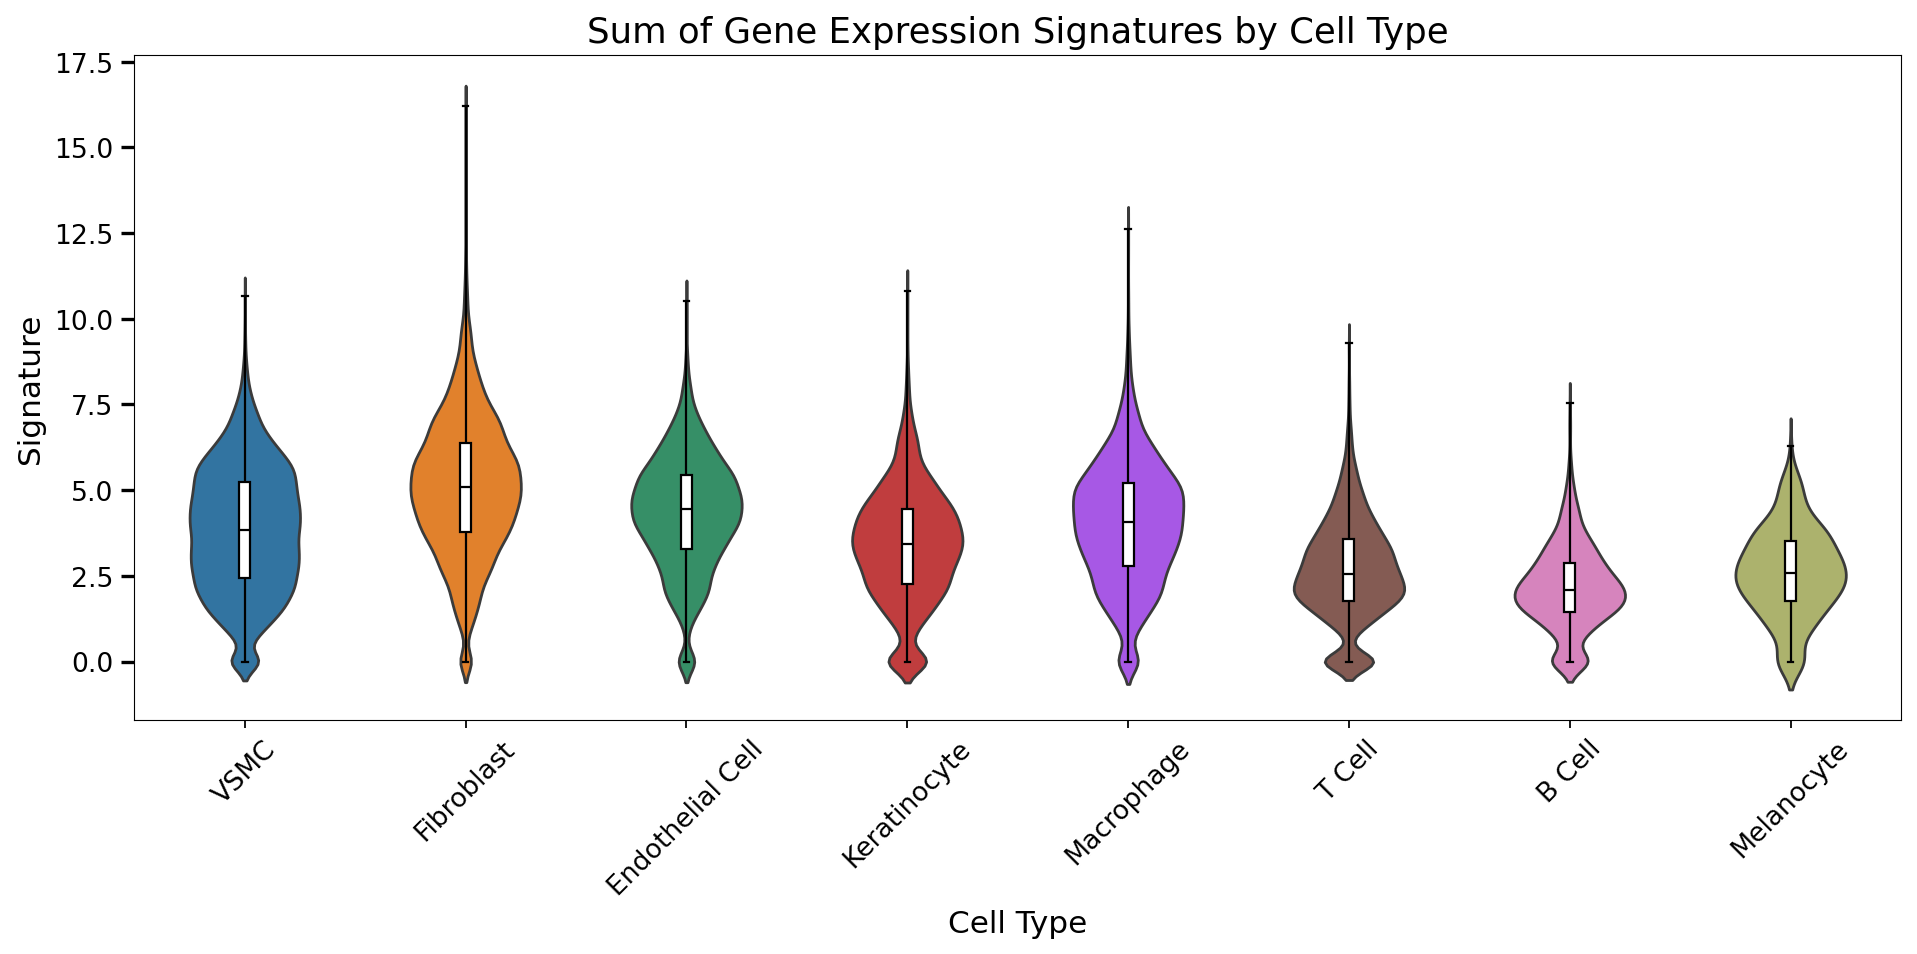

In [62]:
plot_data = adata_loaded.obs[['Signature', 'celltype']]
palette = {
    'VSMC': '#1f77b4',
    'Fibroblast': '#ff7f0e',
    'Endothelial Cell': '#279e68',
    'Keratinocyte': '#d62728',
    'Macrophage': '#aa40fc',
    'T Cell': '#8c564b',
    'B Cell': '#e377c2',
    'Melanocyte': '#b5bd61'
}
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    x='celltype', 
    y='Signature', 
    data=plot_data, 
    inner=None, 
    palette=palette, 
    scale='width', 
    width=0.5,
    ax=ax
)
sns.boxplot(
    x='celltype', 
    y='Signature', 
    data=plot_data, 
    whis=np.inf, 
    color='k', 
    fliersize=0, 
    linewidth=1, 
    width=0.05, 
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),  
    ax=ax
)
ax.set_title("Sum of Gene Expression Signatures by Cell Type", fontsize=16)
ax.set_xlabel("Cell Type", fontsize=14)
ax.set_ylabel("Signature", fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=12)
ax.grid(False) 
ax.get_yaxis().tick_left()  
ax.yaxis.set_tick_params(direction='out', length=6, width=1.5, color='black', labelsize=12)  
for spine in ax.spines.values():
    spine.set_linewidth(0.5)  
plt.tight_layout()
plt.draw()
plt.savefig("signature_distribution.pdf", dpi=600, bbox_inches='tight')
# 显示图像
plt.show()

In [63]:
import itertools


adata_loaded.obs['Signature'] = signatures  
plot_data = adata_loaded.obs[['Signature', 'celltype']]


celltypes = plot_data['celltype'].unique()
p_values = {}

for group1, group2 in itertools.combinations(celltypes, 2):
    group1_data = plot_data[plot_data['celltype'] == group1]['Signature']
    group2_data = plot_data[plot_data['celltype'] == group2]['Signature']
    

    stat, p = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
    p_values[(group1, group2)] = p


for key, p in p_values.items():
    print(f"比较 {key[0]} 和 {key[1]} 的 p 值: {p}")

比较 VSMC 和 Endothelial Cell 的 p 值: 1.4172174811527369e-65
比较 VSMC 和 Fibroblast 的 p 值: 0.0
比较 VSMC 和 T Cell 的 p 值: 0.0
比较 VSMC 和 Macrophage 的 p 值: 2.9522984651709885e-09
比较 VSMC 和 Keratinocyte 的 p 值: 1.7142866275538675e-46
比较 VSMC 和 B Cell 的 p 值: 1.6947776720806873e-207
比较 VSMC 和 Melanocyte 的 p 值: 1.0969253240743469e-35
比较 Endothelial Cell 和 Fibroblast 的 p 值: 6.848151930060459e-119
比较 Endothelial Cell 和 T Cell 的 p 值: 0.0
比较 Endothelial Cell 和 Macrophage 的 p 值: 1.1414781509354431e-21
比较 Endothelial Cell 和 Keratinocyte 的 p 值: 1.2660018289852572e-175
比较 Endothelial Cell 和 B Cell 的 p 值: 0.0
比较 Endothelial Cell 和 Melanocyte 的 p 值: 5.018854044360724e-74
比较 Fibroblast 和 T Cell 的 p 值: 0.0
比较 Fibroblast 和 Macrophage 的 p 值: 1.032878825618946e-223
比较 Fibroblast 和 Keratinocyte 的 p 值: 0.0
比较 Fibroblast 和 B Cell 的 p 值: 0.0
比较 Fibroblast 和 Melanocyte 的 p 值: 1.012768010016745e-107
比较 T Cell 和 Macrophage 的 p 值: 0.0
比较 T Cell 和 Keratinocyte 的 p 值: 9.044632361486435e-120
比较 T Cell 和 B Cell 的 p 值: 4.0772949